<a href="https://colab.research.google.com/github/mithulya-s/churn_prediction/blob/main/ML_Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Importing the nececassy libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:

# Reading the file into a Pandas dataframe
df_raw = pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

#Making a copy and using that for EDA
df=df_raw.copy()


In [ ]:
# Dataset metadata
#Check the why for this and then add

In [15]:
df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Monthly charges and total charges columns look too multicolinear. Check the connection a bit and drop a column if it's too similar.

In [16]:
df.shape

#Number of rows and columns
rows=df.shape[0]
cols= df.shape[1]
print(f"Dataset has {rows} rows and {cols} columns")

Dataset has 7043 rows and 21 columns


In [17]:
#Checking the datatypes
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Total charges is an object dtype, which seems wrong. Have to change the data type into a numeric type.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
#Checking empty strings in categorical columns, by making a new dataframe
obj_cols= df.select_dtypes(include='object').columns
(df[obj_cols] == '').sum()


,0
customerID,0
gender,0
Partner,0
Dependents,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


From the above explorations, we can identify that the 'TotalCharges' column appears to be a column of data type,'object'. However since total charges should be a numeric column, the data type is converted in the follwoing manner to cotinue exploration and to stop it from affecting the pipeline.

In [20]:
#Changing the 'TotalCharge' column, datatype.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [27]:
#Checking the new total charges column
df['TotalCharges'].isnull().sum()

np.int64(11)

In [26]:
# Find missing values in the numeric columns
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


A simple null check proves that, the total charges column after it was coverted to a numeric column contains 11 values which has been replaced with NaN while conversion, therefore the column contains 11 mismatched values.

In [22]:
# Descriptions for the numerical features
#df.describe(include='all').T
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [23]:
# Descriptions for the categorical features
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [57]:
#Numerical column list
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
numeric_columns

#categorical column list
non_numeric_columns = df.select_dtypes(include=['object']).columns.tolist()
non_numeric_columns

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

Plotting the traget distribution to check class imbalances.

In [58]:
# Value distribution of traget variable
print(df['Churn'].value_counts(normalize=True))
df['Churn'].value_counts()



Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


,count
Churn,
No,5174
Yes,1869


Text(0.5, 1.0, 'Churn distribution')

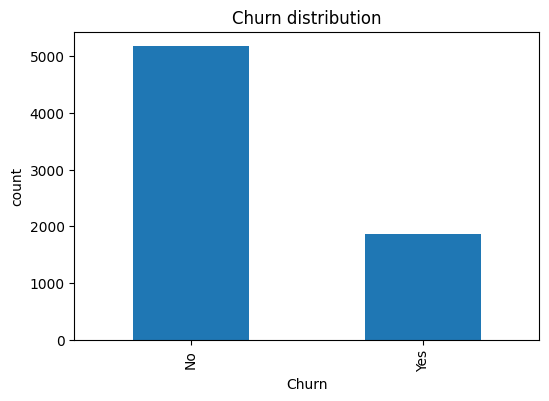

In [59]:
#Plotting the target distriution
plt.figure(figsize=(6, 4))
ax = df['Churn'].value_counts().plot.bar()
ax.set_ylabel('count'); ax.set_title('Churn distribution')

The above plot shows the class imbalanace of the traget distribution, therefore normalising must be done to avoid bias in the modelling phase

## Univariate Analysis
### Numerical features

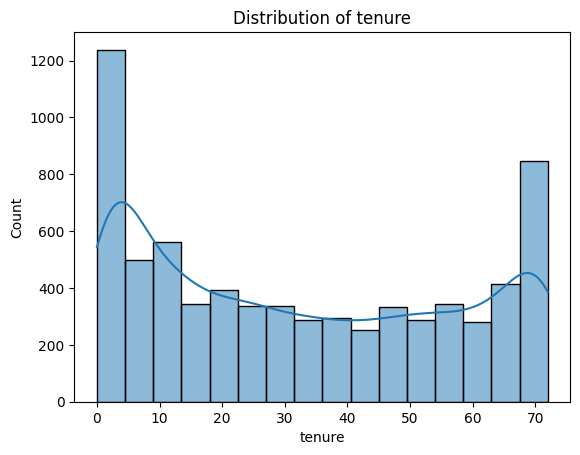

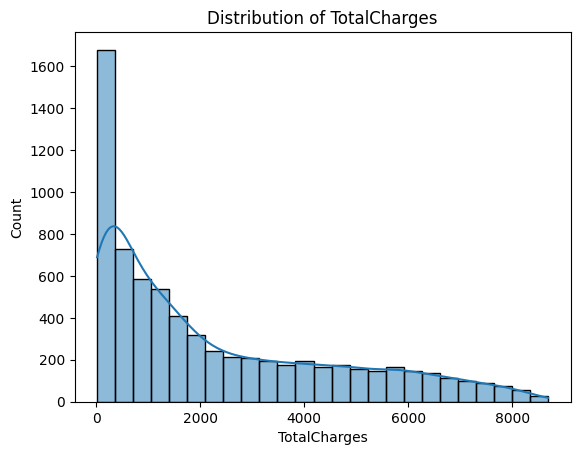

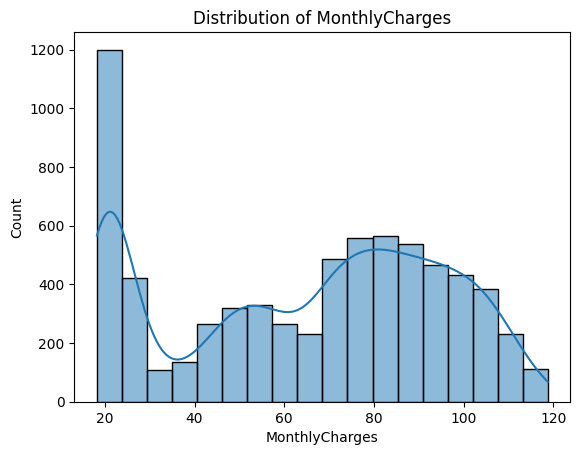

In [60]:
#Plotting the numerical columns such as tenure, total charges, monthly charges, senior citizen
for col in ['tenure', 'TotalCharges', 'MonthlyCharges']:
  sns.histplot(data=df, x=col, kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()



Text(0.5, 1.0, 'Senior citizen distribution')

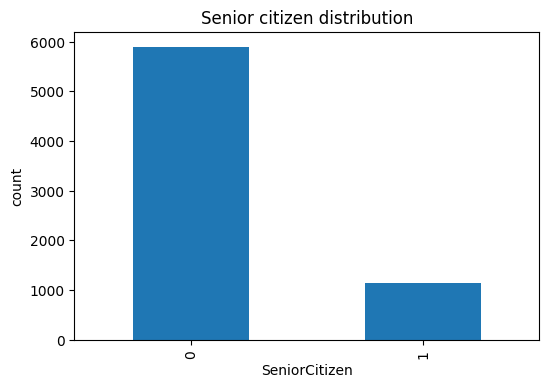

In [61]:
#The other numeric column, but is mostly should be categorical
plt.figure(figsize=(6, 4))
ax = df['SeniorCitizen'].value_counts().plot.bar()
ax.set_ylabel('count'); ax.set_title('Senior citizen distribution')

###Categorical features

In [63]:
#Plotting the categorical features to check the distribution
non_numeric_columns

#Non numeric columns without the ID and Churn columns for plotting
non_numeric_columns.remove('customerID')
non_numeric_columns.remove('Churn')
non_numeric_columns



['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

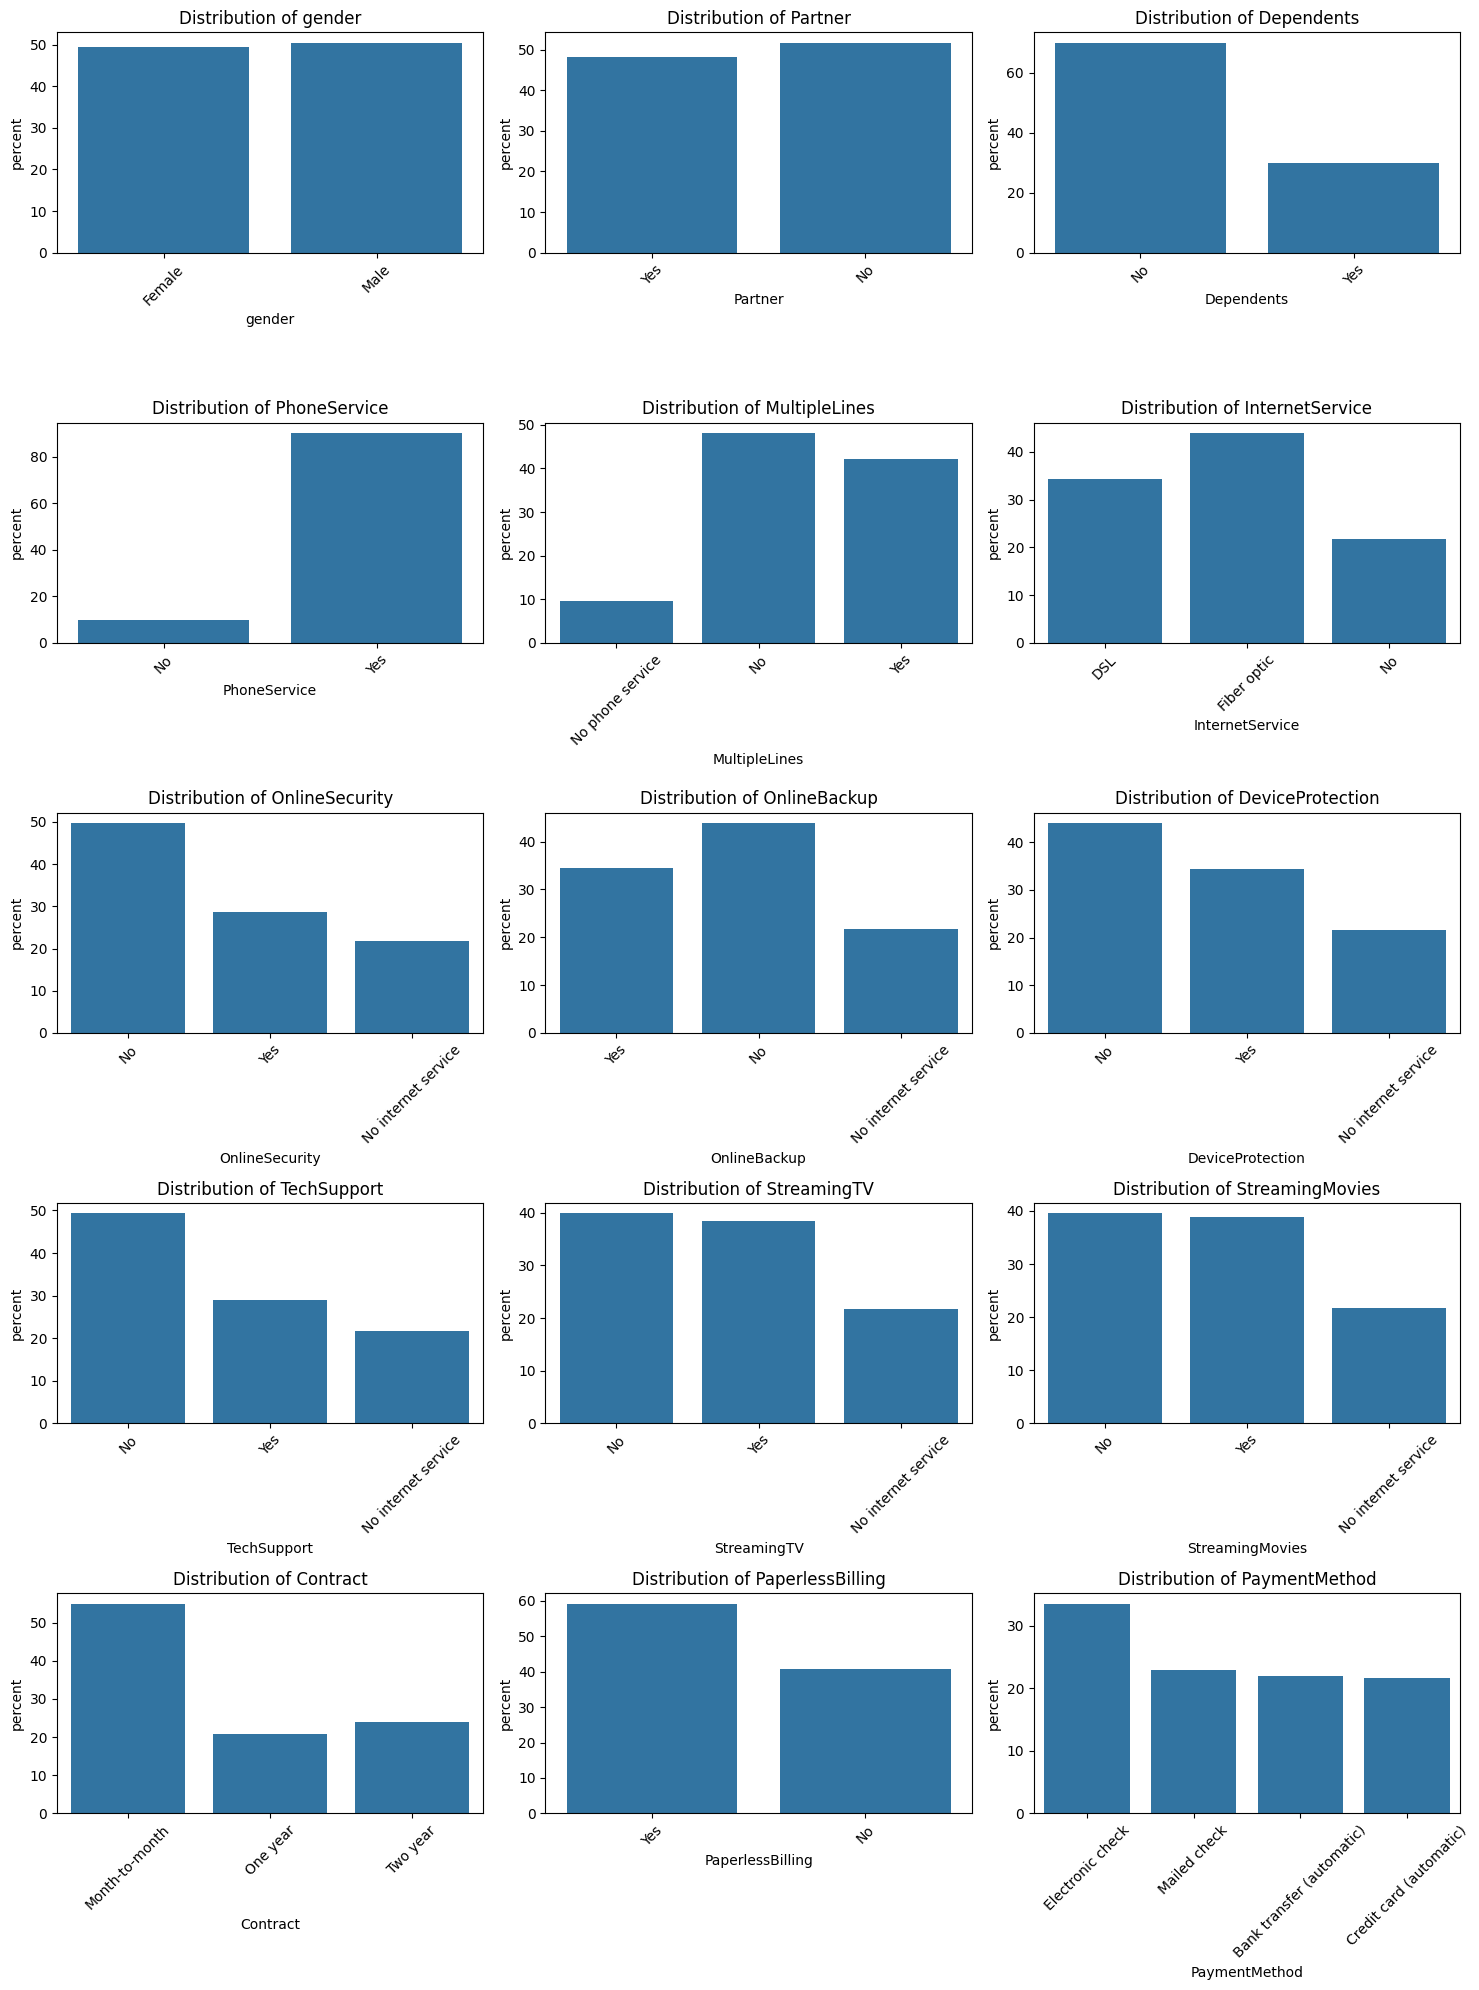

In [65]:
cols_per_row = 3
num_plots = len(non_numeric_columns)
rows = (num_plots + cols_per_row - 1) // cols_per_row

# Create subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 5, rows * 4))
axes = axes.flatten()  # Flatten in case of multiple rows

# Plot each column
for i, col in enumerate(non_numeric_columns):
    sns.countplot(data=df, x=col, ax=axes[i], stat='percent')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Exploratory Data Analysis




*   Tenure : How many months the customer has stayed with the company
*   Phone service: Whether the customer has a phone service or not (Yes, No)
*   MultipleLines: Whether the customer has multiple lines or not (Yes, No, No phone service)
*   Internet service : Customer's internet service provider (DSL, Fiber optic, No)
*   Online secuirty: Whether the customer has online security or not (Yes, No, No internet service)
*   Online backup: Whether the customer has online backup or not (Yes, No, No internet service)
*   Device protection: Whether the customer has device protection or not (Yes, No, No internet service)
*   Tech support: Whether the customer has tech support or not (Yes, No, No internet service)
*   Streaming tv: Whether the customer has streaming TV or not (Yes, No, No internet service)
*   Streaming movies: Whether the customer has streaming movies or not (Yes, No, No internet service)
*   Contract: The contract term of the customer (Month-to-month, One year, Two year)
*   Paperless billing: Whether the customer has paperless billing or not (Yes, No)
*   Payment methods: The customer's payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card)
*   Monthly charges: The amount charged to the customer monthly
*   Total charges : The total amount charged to the customer
*   Churn: Whether the customer churned or not in the past month (Yes or No)







In [ ]:
# Making the columns an array
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

# Data Manipulation

```
# This is formatted as code
```



In [ ]:
# Finding the duplicated rows
duplicated_rows=df[df.duplicated()]
print("number of duplicate rows: ", duplicated_rows.shape)

number of duplicate rows:  (0, 21)


In [ ]:
# new naming conventions for the categories. Have to do it later.

In [ ]:
#Dropping the ID column becuase it's irrelavant.
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


Since the total charges column is an object, we're converting the column into a numeric column since the column should contain numeric values.

In [ ]:
#Transforming the 'total chanrges' column to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#confirming to check the data type
df['TotalCharges'].dtype


dtype('float64')

In [ ]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


After conversion the total charges column has 11 null values. Let's inspect that.

In [ ]:
total_charge_null= df[df['TotalCharges'].isnull()]
total_charge_null

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


When inspected we can see that the tenure values for the NaN charges row are also appears to be zero, though there's a monthly charge on all the records. We will now check if there are other inconsistencies in the 'tenure' column.
Comparing the index values of both the columns


In [ ]:
#checking inconcsistencies in the tenure column
tenure_zeroes=df[df['tenure']==0]
tenure_zeroes

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [ ]:
# Total charges null values index
total_charge_null.index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

In [ ]:
# Index for the tenure=0 rows
tenure_zeroes.index

Index([488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754], dtype='int64')

As it appears, only the saem rows where the total charges have non-numeric values has 0 as the tenure, when we compare the records. Therefore these records must be cleaned.

Since there's only 11 records with the tenure=0, these values are dropped.

In [ ]:
#Dropping the tenure=0 records
df.drop(df[df['tenure']==0].index, inplace=True)

#to confirm the whether they have been cleaned.
df[df['tenure']==0].index

Index([], dtype='int64')

Now to remove the inconsistencies of the total charges column, I decided to replace the values with the median. Since when adding the mean, the mean is also affected by outliers.

In [ ]:
# Replacing the NaN values of the total charges column
# new pandas method, data is chnaged in the original object.
df.fillna({'TotalCharges': df['TotalCharges'].median()}, inplace=True)

#Checking the earlier Nan values.
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


Normalizing the data types of the column to have Better visualizations

In [ ]:
#Changing the 'senior citizen' dtype pf int -> object by mapping
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [ ]:
df.head(20)
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [ ]:
#getting the numeric column names
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
numeric_columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [ ]:
#Getting the non-numeric columns
non_numeric_columns = df.select_dtypes(include=['object']).columns.tolist()
non_numeric_columns

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

# Data Visualization

## Numeric Columns
Visualizing the numeric columns

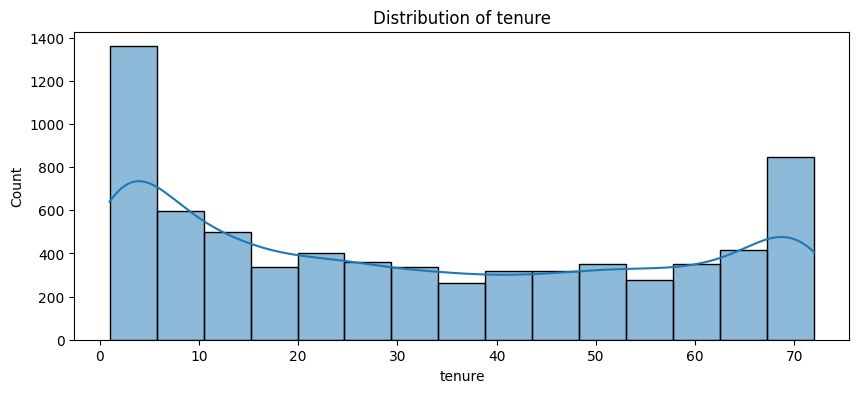

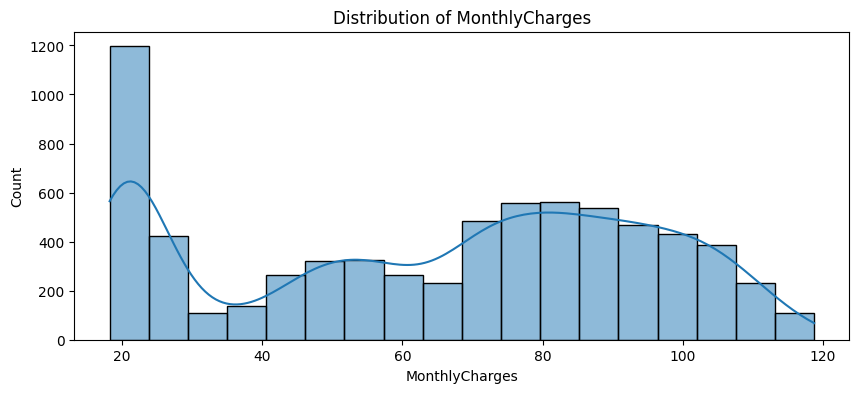

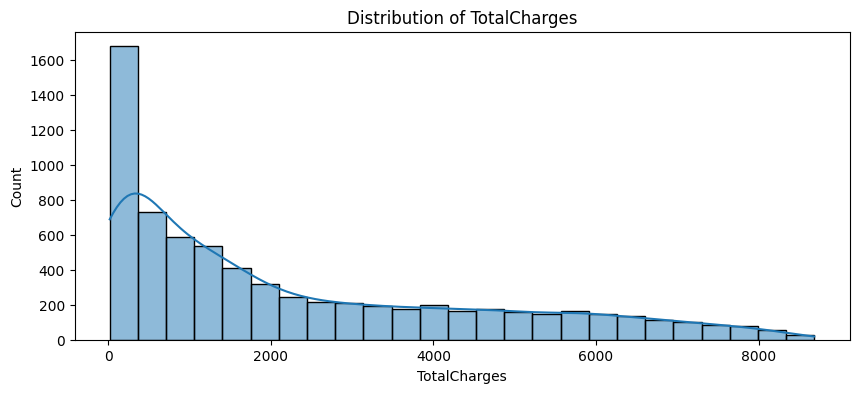

In [ ]:
#visualizing the numeric columns in a side by side way
for col in numeric_columns:
  plt.figure(figsize=(10,4))
  sns.histplot(data=df, x=col, kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()


## Visualizing the non-numeric columns

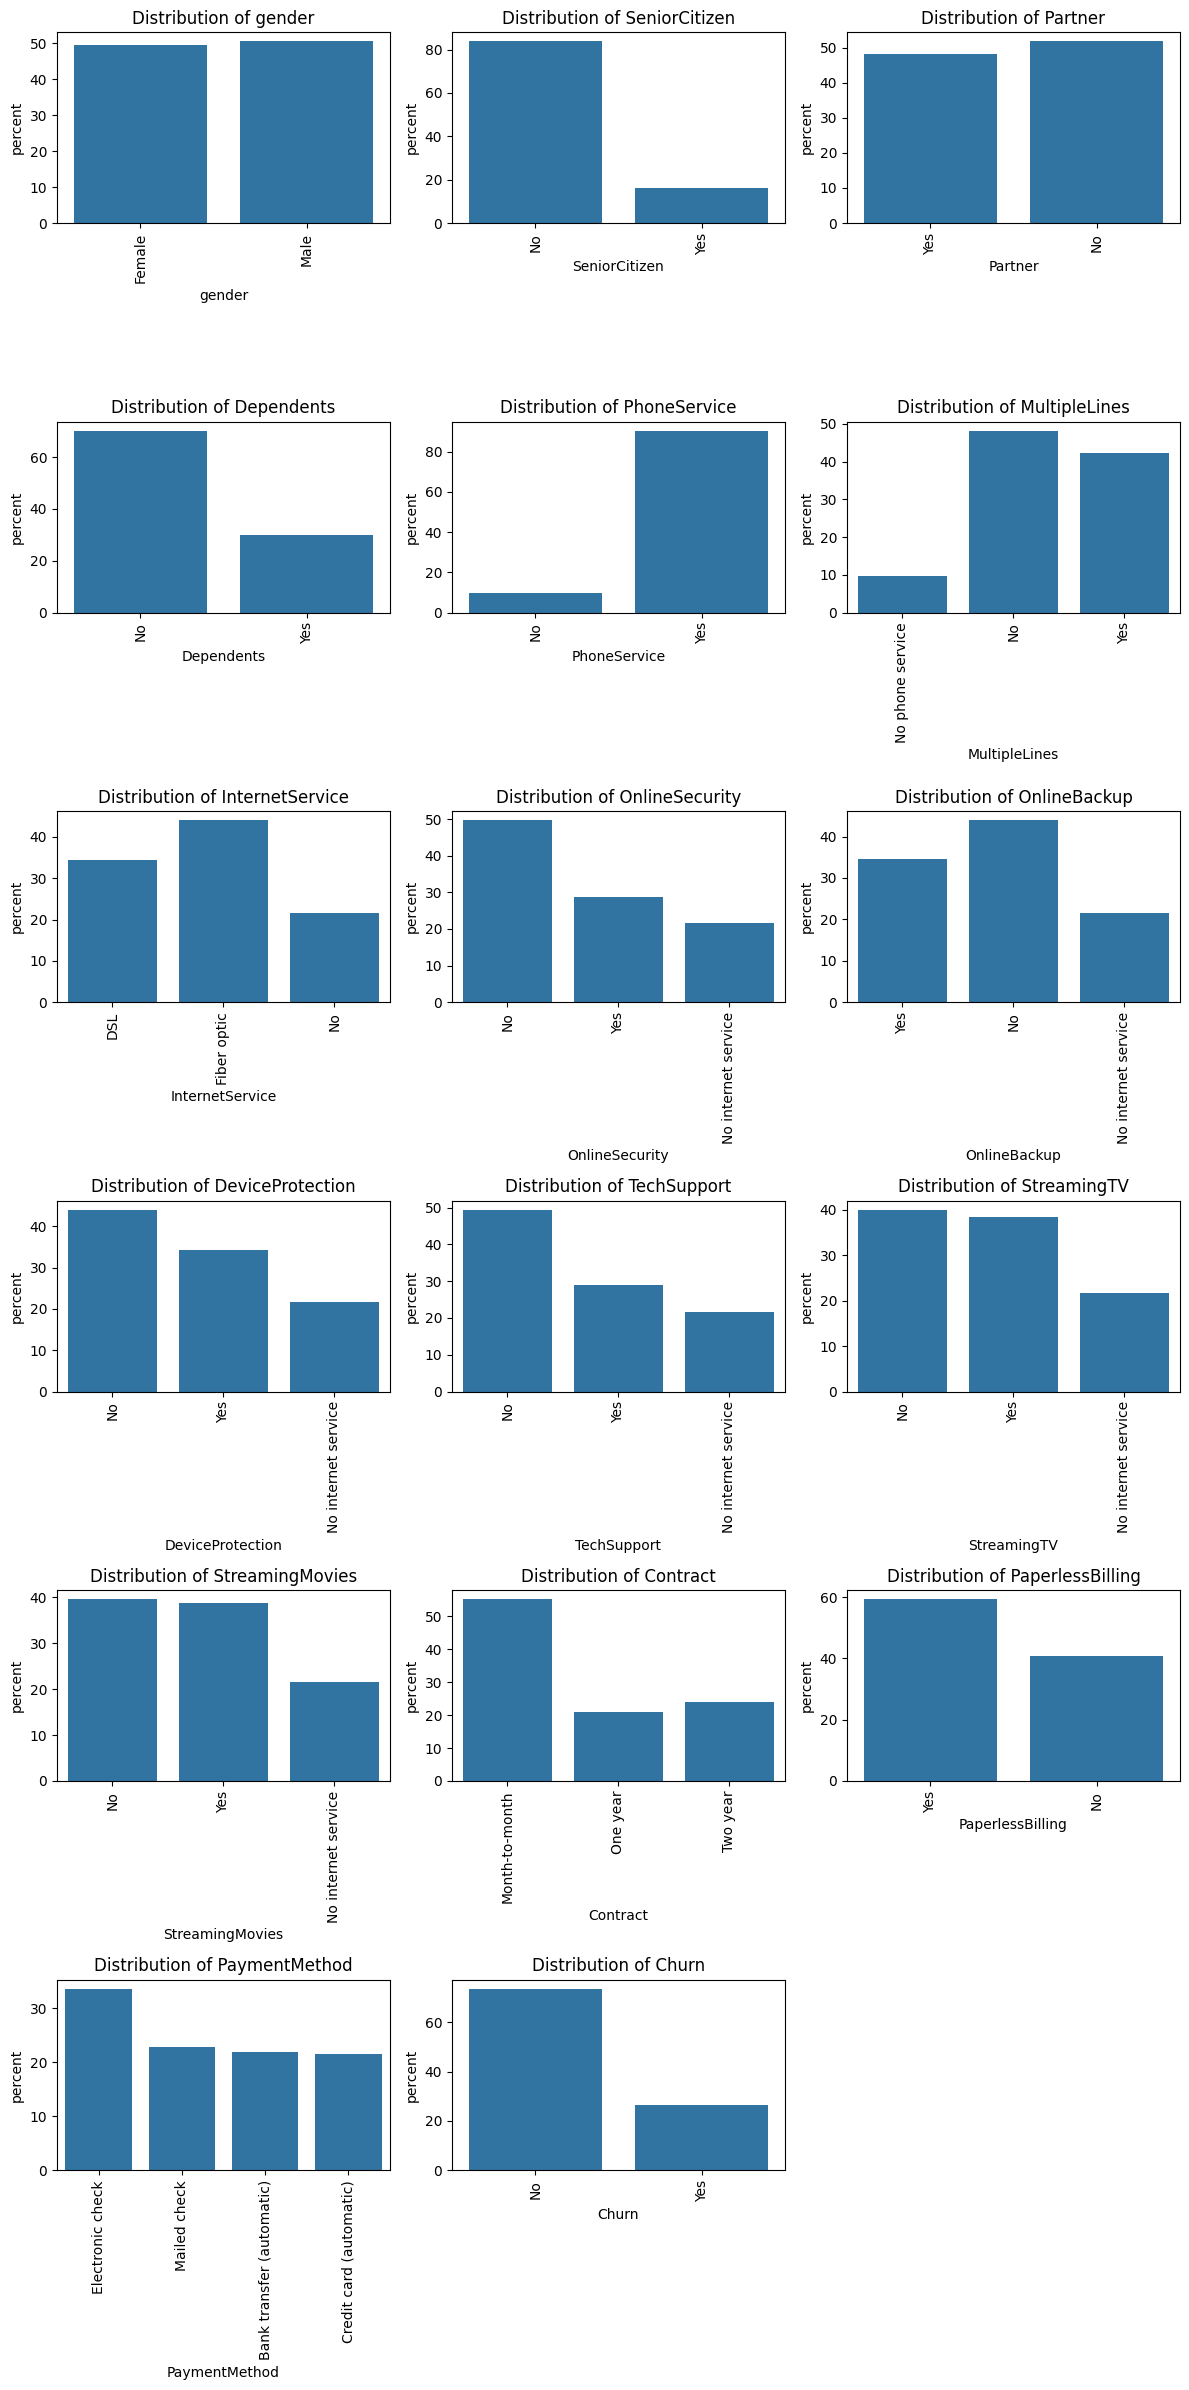

In [ ]:
cols_per_row = 3
num_plots = len(non_numeric_columns)
rows = (num_plots + cols_per_row - 1) // cols_per_row

# Create subplots
fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 4, rows * 4))
axes = axes.flatten()  # Flatten in case of multiple rows

# Plot each column
for i, col in enumerate(non_numeric_columns):
    sns.countplot(data=df, x=col, ax=axes[i], stat='percent')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=90)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Data Preprocessing

Enconding non-numeric columns

In [ ]:
# Splitting the data
from sklearn.model_selection import train_test_split
train_X, test_X, train_y,test_y=train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Creating a decision tree classifeir model
from sklearn.tree import DecisionTreeClassifier
classifier_mod= DecisionTreeClassifier(max_depth=4,min_samples_split=20, min_samples_leaf=15,
    class_weight='balanced',
    random_state=42)
classifier_mod

DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                       min_samples_leaf=15, min_samples_split=20,
                       random_state=42)

In [ ]:
# Fitting the model
classifier_mod.fit(train_X, train_y)

DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                       min_samples_leaf=15, min_samples_split=20,
                       random_state=42)

In [ ]:
# Predicting the values
val_predictions = classifier_mod.predict(test_X)

In [ ]:
#Evaluating the accuracy, precision, recall and F1 score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(test_y, val_predictions)
print(f"Accuracy:{accuracy:.3f}")


Accuracy:0.729


In [ ]:
# Get predictions
train_pred = classifier_mod.predict(train_X)
test_pred = classifier_mod.predict(test_X)

# Compare scores
train_acc = accuracy_score(train_y, train_pred)
test_acc = accuracy_score(test_y, test_pred)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy: {test_acc:.3f}")
print(f"Difference: {train_acc - test_acc:.3f}")

Train accuracy: 0.769
Test accuracy: 0.729
Difference: 0.041


In [ ]:
print(f"Tree depth: {classifier_mod.tree_.max_depth}")

Tree depth: 4
